# 01 — Diagnostic du signal (FinBERT + Momentum)

**Objectif** : comprendre empiriquement la qualité du signal sur les données disponibles (mars–mai 2026).

On va répondre à 4 questions :
1. Le sentiment FinBERT varie-t-il vraiment jour après jour, ou est-il quasi-statique ?
2. Le momentum min-max est-il clampé (problème connu) ? De combien ?
3. Le signal prédit-il le rendement J+1 (corrélation) ?
4. Quelle pondération sentiment/momentum serait empiriquement meilleure ?

> Ce notebook ne modifie aucun fichier source. Il est 100 % read-only.

In [1]:
import sys
from pathlib import Path

# Ajouter le dossier parent pour les imports backtesting_2
ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

TICKERS = ["NKE", "TGT", "DIS", "SBUX", "TSLA"]
DATA_INPUT = ROOT / 'backtesting_2' / 'data_input'
DATA_OUTPUT = ROOT / 'backtesting_2' / 'data_output'
COLORS = {'NKE': '#1f77b4', 'TGT': '#ff7f0e', 'DIS': '#2ca02c', 'SBUX': '#d62728', 'TSLA': '#9467bd'}

print(f"Root : {ROOT}")
files_2026 = sorted(DATA_INPUT.glob('alphavantage_merged_2026*.json'))
print(f"Fichiers 2026 disponibles : {len(files_2026)} ({files_2026[0].stem[-8:]} → {files_2026[-1].stem[-8:]})")

Root : /Users/julio/Developer/Portfolio-Management-MODS
Fichiers 2026 disponibles : 102 (20260102 → 20260529)


## 1. Chargement des scores pré-calculés (data_output)

In [2]:
sent_df = pd.read_csv(DATA_OUTPUT / 'daily_sentiment_scores.csv', parse_dates=['date'])
mom_df  = pd.read_csv(DATA_OUTPUT / 'daily_momentum_scores.csv',  parse_dates=['date'])
glob_df = pd.read_csv(DATA_OUTPUT / 'daily_global_scores.csv',    parse_dates=['date'])
wts_df  = pd.read_csv(DATA_OUTPUT / 'daily_weights.csv',          parse_dates=['date'])

dates = sorted(glob_df['date'].unique())
print(f"Période couverte : {dates[0].date()} → {dates[-1].date()} ({len(dates)} jours)")

# Pivoter pour avoir tickers en colonnes
sent_piv = sent_df.pivot(index='date', columns='ticker', values='sentiment_score')
mom_piv  = mom_df.pivot( index='date', columns='ticker', values='momentum_score')
glob_piv = glob_df.pivot(index='date', columns='ticker', values='global_score')

glob_piv.tail()

Période couverte : 2026-01-02 → 2026-05-28 (101 jours)


ticker,DIS,NKE,SBUX,TGT,TSLA
date,,,,,
2026-05-21,0.161464,-0.459811,0.506841,0.650369,0.569906
2026-05-22,0.010799,-0.505165,0.145908,0.265121,0.403707
2026-05-26,0.477776,-0.278602,-0.223736,0.610849,0.739046
2026-05-27,-0.026070,-0.033880,0.215813,0.209771,0.593648
2026-05-28,0.184579,-0.506288,-0.203640,0.609492,0.720638


## 2. Distribution du sentiment FinBERT

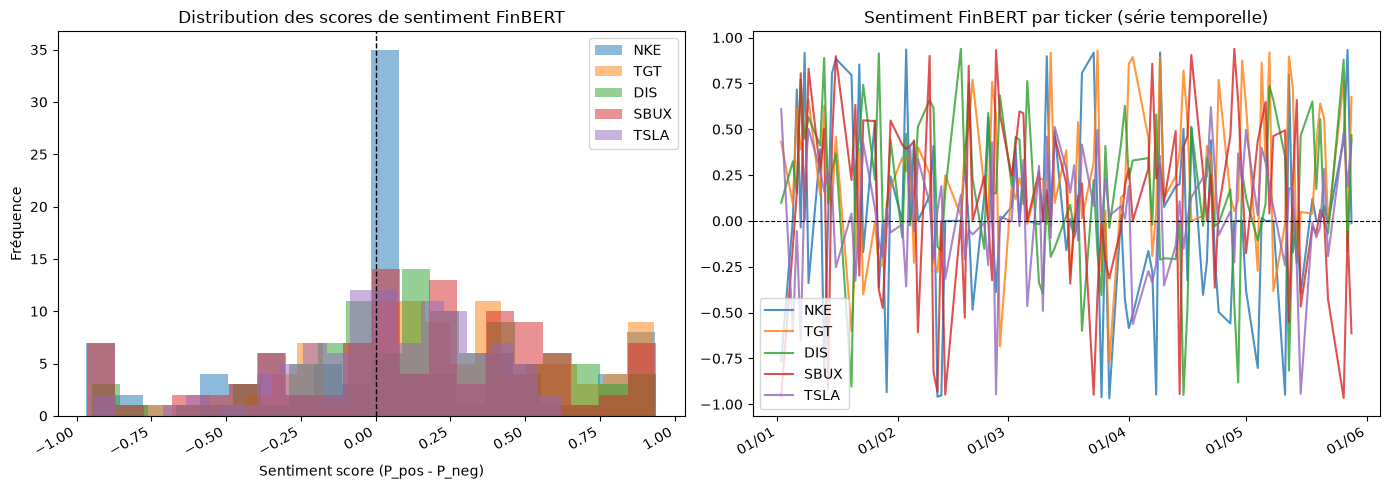


Stats sentiment par ticker :
ticker       DIS       NKE      SBUX       TGT      TSLA
count   101.0000  101.0000  101.0000  101.0000  101.0000
mean      0.1717    0.0197    0.1132    0.2414    0.0446
std       0.4008    0.4848    0.4843    0.3828    0.3095
min      -0.9493   -0.9680   -0.9656   -0.7732   -0.9465
25%      -0.0375   -0.1922   -0.0655    0.0000   -0.1120
50%       0.1610    0.0000    0.1965    0.1890    0.0561
75%       0.4576    0.2660    0.4618    0.5132    0.2760
max       0.9381    0.9347    0.9386    0.9294    0.6203


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme par ticker
ax = axes[0]
for t in TICKERS:
    if t in sent_piv.columns:
        ax.hist(sent_piv[t].dropna(), bins=20, alpha=0.5, label=t, color=COLORS[t])
ax.axvline(0, color='black', lw=1, ls='--')
ax.set_title('Distribution des scores de sentiment FinBERT')
ax.set_xlabel('Sentiment score (P_pos - P_neg)')
ax.set_ylabel('Fréquence')
ax.legend()

# Série temporelle
ax = axes[1]
for t in TICKERS:
    if t in sent_piv.columns:
        ax.plot(sent_piv.index, sent_piv[t], label=t, color=COLORS[t], alpha=0.8)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_title('Sentiment FinBERT par ticker (série temporelle)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
ax.legend()
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

# Stats résumées
print("\nStats sentiment par ticker :")
print(sent_piv.describe().round(4))

## 3. Diagnostic du clampage min-max du momentum

Observations momentum clampées à ±1 : 202/505 = 40.0%

Par ticker :
  NKE: 63/101 = 62% clampés | moy=-0.853 std=0.246
  TGT: 79/101 = 78% clampés | moy=0.905 std=0.209
  DIS: 8/101 = 8% clampés | moy=-0.301 std=0.449
  SBUX: 12/101 = 12% clampés | moy=0.504 std=0.370
  TSLA: 40/101 = 40% clampés | moy=-0.422 std=0.648


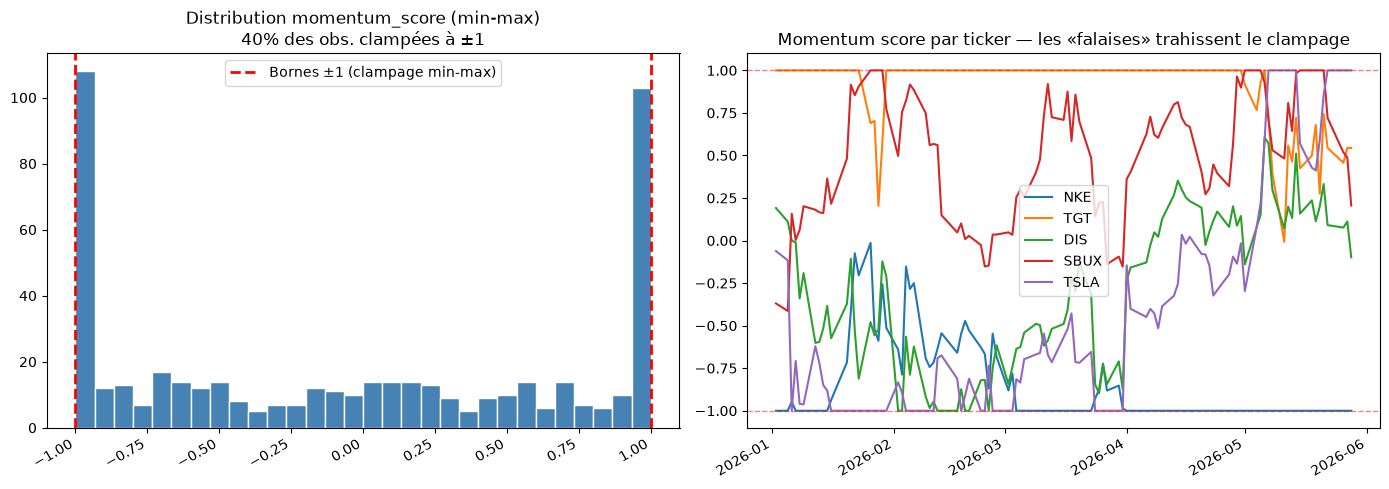

In [4]:
# Combien d'observations sont collées à ±1 ?
all_mom = mom_piv.values.flatten()
all_mom = all_mom[~np.isnan(all_mom)]
clamped = np.sum(np.abs(all_mom) >= 0.999)
total   = len(all_mom)
print(f"Observations momentum clampées à ±1 : {clamped}/{total} = {100*clamped/total:.1f}%")

# Par ticker
print("\nPar ticker :")
for t in TICKERS:
    if t in mom_piv.columns:
        col = mom_piv[t].dropna()
        c = (col.abs() >= 0.999).sum()
        print(f"  {t}: {c}/{len(col)} = {100*c/len(col):.0f}% clampés | moy={col.mean():.3f} std={col.std():.3f}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(all_mom, bins=30, color='steelblue', edgecolor='white')
ax.axvline(-1, color='red', lw=2, ls='--', label='Bornes ±1 (clampage min-max)')
ax.axvline(+1, color='red', lw=2, ls='--')
ax.set_title(f'Distribution momentum_score (min-max)\n{100*clamped/total:.0f}% des obs. clampées à ±1')
ax.legend()

ax = axes[1]
for t in TICKERS:
    if t in mom_piv.columns:
        ax.plot(mom_piv.index, mom_piv[t], label=t, color=COLORS[t])
ax.axhline(-1, color='red', lw=1, ls='--', alpha=0.5)
ax.axhline(+1, color='red', lw=1, ls='--', alpha=0.5)
ax.set_title('Momentum score par ticker — les «falaises» trahissent le clampage')
ax.legend()
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

## 4. Le signal prédit-il le rendement J+1 ?

On calcule la corrélation de Spearman entre `global_score(J)` et `return(J→J+1)` pour chaque ticker.

In [5]:
import yfinance as yf

# Télécharger les prix sur la période
start = str(glob_piv.index.min().date())
end   = str((glob_piv.index.max() + pd.Timedelta(days=5)).date())
prices_raw = yf.download(TICKERS, start=start, end=end, auto_adjust=True, progress=False)['Close']
returns_fwd = prices_raw.pct_change().shift(-1)  # rendement J→J+1

print(f"Prix téléchargés : {prices_raw.index[0].date()} → {prices_raw.index[-1].date()}")

# Corrélation signal global → rendement J+1
results = []
for t in TICKERS:
    if t not in glob_piv.columns or t not in returns_fwd.columns:
        continue
    df_t = pd.DataFrame({
        'signal': glob_piv[t],
        'fwd_ret': returns_fwd[t].reindex(glob_piv.index)
    }).dropna()
    if len(df_t) < 5:
        continue
    rho, pval = stats.spearmanr(df_t['signal'], df_t['fwd_ret'])
    results.append({'ticker': t, 'n': len(df_t), 'rho_spearman': round(rho, 4), 'p_value': round(pval, 4)})

corr_df = pd.DataFrame(results)
print("\nCorrélation Spearman : global_score(J) vs rendement(J→J+1)")
print(corr_df.to_string(index=False))
print("\n(rho > 0.15 et p < 0.10 : signal faiblement prédictif ; rho > 0.30 : signal utile)")

Prix téléchargés : 2026-01-02 → 2026-06-01

Corrélation Spearman : global_score(J) vs rendement(J→J+1)
ticker   n  rho_spearman  p_value
   NKE 101        0.0684   0.4969
   TGT 101       -0.0564   0.5753
   DIS 101       -0.0611   0.5439
  SBUX 101       -0.0467   0.6426
  TSLA 101        0.1368   0.1724

(rho > 0.15 et p < 0.10 : signal faiblement prédictif ; rho > 0.30 : signal utile)


In [6]:
# Décomposition : sentiment seul vs momentum seul
print("Corrélation Spearman par composante du signal :\n")
rows = []
for t in TICKERS:
    fwd = returns_fwd[t].reindex(glob_piv.index) if t in returns_fwd.columns else pd.Series(dtype=float)
    row = {'ticker': t}
    for label, col_piv in [('sentiment', sent_piv), ('momentum_minmax', mom_piv), ('global_score', glob_piv)]:
        if t in col_piv.columns:
            df_t = pd.DataFrame({'s': col_piv[t], 'r': fwd}).dropna()
            if len(df_t) >= 5:
                rho, _ = stats.spearmanr(df_t['s'], df_t['r'])
                row[label] = round(rho, 4)
            else:
                row[label] = np.nan
    rows.append(row)

print(pd.DataFrame(rows).to_string(index=False))

Corrélation Spearman par composante du signal :

ticker  sentiment  momentum_minmax  global_score
   NKE     0.1422          -0.1385        0.0684
   TGT     0.0101          -0.0561       -0.0564
   DIS    -0.1027           0.0253       -0.0611
  SBUX     0.1473          -0.3086       -0.0467
  TSLA     0.1681           0.0711        0.1368


## 5. Quelle pondération sentiment/momentum est empiriquement meilleure ?

On balaie toutes les combinaisons `α × sentiment + (1-α) × momentum` et on cherche le α qui maximise la corrélation moyenne avec le rendement J+1.

Meilleur α empirique : 1.00  (sentiment=100%, momentum=0%)
Corrélation moyenne à ce α : 0.0730
Corrélation à α=0.50 (actuel) : 0.0082


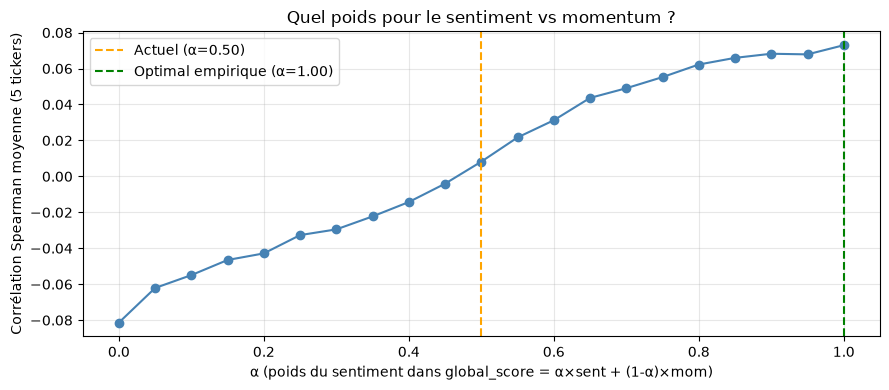

In [7]:
alphas = np.linspace(0, 1, 21)  # 0.00, 0.05, ..., 1.00
mean_rhos = []

for alpha in alphas:
    rhos = []
    for t in TICKERS:
        if t not in sent_piv.columns or t not in mom_piv.columns:
            continue
        combined = alpha * sent_piv[t] + (1 - alpha) * mom_piv[t]
        fwd = returns_fwd[t].reindex(combined.index) if t in returns_fwd.columns else pd.Series(dtype=float)
        df_t = pd.DataFrame({'s': combined, 'r': fwd}).dropna()
        if len(df_t) >= 5:
            rho, _ = stats.spearmanr(df_t['s'], df_t['r'])
            rhos.append(rho)
    mean_rhos.append(np.mean(rhos) if rhos else 0)

best_alpha = alphas[np.argmax(mean_rhos)]
print(f"Meilleur α empirique : {best_alpha:.2f}  (sentiment={best_alpha:.0%}, momentum={1-best_alpha:.0%})")
print(f"Corrélation moyenne à ce α : {max(mean_rhos):.4f}")
print(f"Corrélation à α=0.50 (actuel) : {mean_rhos[10]:.4f}")

plt.figure(figsize=(9, 4))
plt.plot(alphas, mean_rhos, 'o-', color='steelblue')
plt.axvline(0.5, color='orange', ls='--', label='Actuel (α=0.50)')
plt.axvline(best_alpha, color='green', ls='--', label=f'Optimal empirique (α={best_alpha:.2f})')
plt.xlabel('α (poids du sentiment dans global_score = α×sent + (1-α)×mom)')
plt.ylabel('Corrélation Spearman moyenne (5 tickers)')
plt.title('Quel poids pour le sentiment vs momentum ?')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Synthèse

Ce notebook a quantifié :
- La distribution et la variabilité du sentiment FinBERT
- Le taux de clampage du momentum min-max (problème principal confirmé)
- La corrélation prédictive signal → rendement J+1
- Le poids optimal empirique sentiment/momentum

→ **Voir Notebook 02** pour la correction du clampage (z-score vs min-max)  
→ **Voir Notebook 03** pour la calibration walk-forward des poids